## Digit Recognitiion Model using Numpy only

# Data Preprocessing

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 


In [56]:
train = pd.read_csv("train.csv")
X_test = pd.read_csv("test.csv")

In [57]:
train.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [58]:
train.shape

(42000, 785)

In [59]:
train.isnull().sum()

label       0
pixel0      0
pixel1      0
pixel2      0
pixel3      0
           ..
pixel779    0
pixel780    0
pixel781    0
pixel782    0
pixel783    0
Length: 785, dtype: int64

In [60]:
X = train.drop("label",axis=1)
Y = train["label"]


# Sample Image


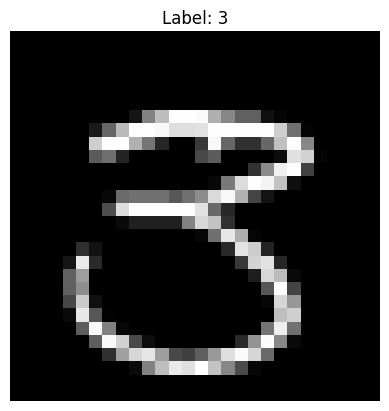

In [61]:
image = X.iloc[7].values.reshape(28,28)
plt.imshow(image, cmap="gray")
plt.title(f"Label: {Y.iloc[7]}")
plt.axis("off")
plt.show()

In [62]:
X = X.to_numpy()
Y =Y.to_numpy()

In [63]:
#Normalizing the Pixel values
X = X/255


In [64]:
print(X.min())
print(X.max())

0.0
1.0


In [65]:
print(X.shape)
Y = Y.reshape(-1,1)
Y = Y.T
print(Y.shape)

(42000, 784)
(1, 42000)


In [66]:
X = X.T
print(X.shape)

(784, 42000)


# Neural Network

In [67]:
def initialize_parameters(layer_dims):
    np.random.seed(42)
    parameters = {}
    L = len(layer_dims)
    for l in range(1,L):
        parameters["W" + str(l)] = np.random.randn(layer_dims[l],layer_dims[l-1])*0.01
        parameters["b" + str(l)] = np.zeros((layer_dims[l],1))
    return parameters

In [68]:
def RELU(Z):
    A = np.maximum(0,Z)
    cache = Z
    return A,cache

In [69]:
def softmax(Z):
    Z_shift = Z - np.max(Z, axis=0, keepdims=True)
    exp_Z = np.exp(Z_shift)
    A = exp_Z / np.sum(exp_Z, axis=0, keepdims=True)
    cache = Z
    return A, cache

In [70]:
def linear_forward(A_prev,W,b):
    Z = np.dot(W,A_prev)+b
    cache = (A_prev,W,b)
    return Z,cache

In [71]:
def linear_activation_forward(A_prev,W,b,activation):
    Z,linear_cache = linear_forward(A_prev,W,b)
    if activation == "relu":
        A,activation_cache = RELU(Z)
    elif activation == "softmax":
        A,activation_cache = softmax(Z)
    cache = (linear_cache,activation_cache)
    return  A,cache

In [72]:
def model_forward(X,parameters):
    L = len(parameters)//2
    A = X
    caches = []
    for l in range(1,L):
        A,cache = linear_activation_forward(A,parameters["W" + str(l)],parameters["b" + str(l)],activation = "relu")
        caches.append(cache)
    AL,cache = linear_activation_forward(A,parameters["W" + str(L)], parameters["b" + str(L)],activation = "softmax")
    caches.append(cache)
    return AL,caches

In [73]:
layer_dims = [784,128,64,10]
parameters = initialize_parameters(layer_dims)
AL, caches = model_forward(X, parameters)

print(AL.shape)
print(len(caches))

(10, 42000)
3


In [74]:
def one_hot_encode(Y, num_classes=10):
    m = Y.shape[1]
    Y_one_hot = np.zeros((num_classes, m))
    for i in range(m):
        label = int(Y[0, i])
        Y_one_hot[label, i] = 1

    return Y_one_hot

In [75]:
Y = one_hot_encode(Y,)
Y.shape

(10, 42000)

In [76]:
def compute_cost(AL,Y):
    m = Y.shape[1]
    epsilon = 1e-8
    cost = -np.sum(Y * np.log(AL + epsilon))/m
    return cost

In [77]:
cost = compute_cost(AL,Y)
print(cost)

2.3026085797821962


In [78]:
def relu_backward(dA,activation_cache):
    Z = activation_cache
    dZ = np.array(dA,copy=True)
    dZ[Z<=0] = 0
    return dZ

In [79]:
def softmax_backward(AL,Y):
    dZ = AL - Y
    return dZ

In [80]:
def linear_backward(dZ,linear_cache):
    A_prev,W,b = linear_cache
    m = A_prev.shape[1]
    dW = (1/m)*np.dot(dZ,A_prev.T)
    db = (1/m) * np.sum(dZ,axis=1,keepdims=True)
    dA_prev = np.dot(W.T,dZ)
    
    return dA_prev,dW,db

In [81]:
def linear_activation_backward(dA,caches, activation):
    linear_cache,activation_cache = caches
    if activation == "relu":
        dZ = relu_backward(dA,activation_cache)
        dA_prev,dW,db = linear_backward(dZ,linear_cache)
    return dA_prev,dW,db

In [82]:
def backward_propagation(AL,Y,caches):
    grads = {}
    L = len(caches)
    dZL = softmax_backward(AL,Y)
    dA_prev,dW,db = linear_backward(dZL,caches[L-1][0])
    grads["dW" + str(L)] = dW
    grads["db" + str(L)] = db
    
    for l in reversed(range(1,L)):
        dA_prev,dW,db = linear_activation_backward(dA_prev,caches[l-1],activation="relu")
        grads["dW" + str(l)] = dW
        grads["db" + str(l)] = db
    return grads

In [83]:
def update_params(parameters,grads,learning_rate):
    L = len(parameters)//2
    for l in range(1,L+1):
        parameters["W" + str(l)] -= learning_rate*grads["dW"+str(l)]
        parameters["b" + str(l)] -= learning_rate*grads["db"+str(l)]
    return parameters

In [84]:
grads = backward_propagation(AL,Y,caches)
print(grads["dW1"].shape)
print(grads["db1"].shape)
print(grads["dW2"].shape)
print(grads["db2"].shape)
print(grads["dW3"].shape)
print(grads["db3"].shape)

(128, 784)
(128, 1)
(64, 128)
(64, 1)
(10, 64)
(10, 1)


In [85]:
print(np.linalg.norm(grads["dW1"]))
print(np.linalg.norm(grads["dW2"]))
print(np.linalg.norm(grads["dW3"]))

0.0035314867101538237
0.0036293911419422015
0.0032225771754371187


# Model Training

In [86]:
def model(X,Y,layer_dims,learning_rate= 0.1,epochs= 3000,print_cost = True):
    parameters = initialize_parameters(layer_dims)
    costs = []
    for i in range(epochs):
        AL, caches = model_forward(X,parameters)
        cost = compute_cost(AL,Y)
        grads = backward_propagation(AL,Y,caches)
        parameters = update_params(parameters,grads,learning_rate)
        
        if i%100 == 0:
            costs.append(cost)
            if print_cost:
                print(f"Iteration {i} : Cost {cost:.6f}")
                
    print(f"Iteration {epochs} : Cost {cost:.6f}")
    plt.plot(costs)
    plt.xlabel("Iterations")
    plt.ylabel("Cost")
    plt.title("Cost Curve")
    plt.show()
    
    return AL,parameters

Iteration 0 : Cost 2.302609
Iteration 100 : Cost 2.300816
Iteration 200 : Cost 2.298887
Iteration 300 : Cost 2.280974
Iteration 400 : Cost 1.476053
Iteration 500 : Cost 0.707001
Iteration 600 : Cost 0.610589
Iteration 700 : Cost 0.544614
Iteration 800 : Cost 0.491286
Iteration 900 : Cost 0.428208
Iteration 1000 : Cost 0.376889
Iteration 1100 : Cost 0.340807
Iteration 1200 : Cost 0.312763
Iteration 1300 : Cost 0.289098
Iteration 1400 : Cost 0.268172
Iteration 1500 : Cost 0.249201
Iteration 1600 : Cost 0.232036
Iteration 1700 : Cost 0.216732
Iteration 1800 : Cost 0.203132
Iteration 1900 : Cost 0.191033
Iteration 2000 : Cost 0.180284
Iteration 2100 : Cost 0.170701
Iteration 2200 : Cost 0.162055
Iteration 2300 : Cost 0.154199
Iteration 2400 : Cost 0.147017
Iteration 2500 : Cost 0.140384
Iteration 2600 : Cost 0.134204
Iteration 2700 : Cost 0.128458
Iteration 2800 : Cost 0.123088
Iteration 2900 : Cost 0.118066
Iteration 3000 : Cost 0.113403


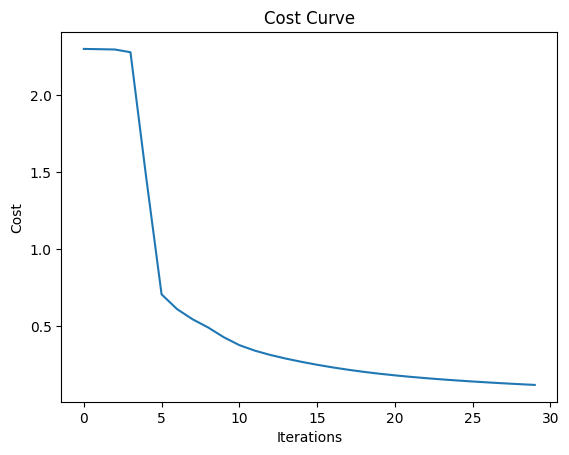

In [54]:
AL,parameters = model(X,Y,layer_dims)

# Prediction

In [87]:
def predict(X,parameters):
    AL,_ = model_forward(X,parameters)
    predictions = np.argmax(AL,axis=0)
    return predictions

In [88]:
train_predictions = predict(X,parameters)

In [89]:
X_test = X_test.to_numpy()
X_test = X_test.T
X_test = X_test/255
test_prediction = predict(X_test,parameters)

In [90]:
print(X.shape)
print(Y.shape)
print(X_test.shape)
print(train_predictions.shape)
print(test_prediction.shape)

(784, 42000)
(10, 42000)
(784, 28000)
(42000,)
(28000,)


# Final Submission

In [48]:
submission = pd.DataFrame({"ImageId" : np.arange(1,len(test_prediction)+1),
                           "Label" : test_prediction
                           })

In [49]:
submission.head()

,ImageId,Label
0,1,2
1,2,0
2,3,9
3,4,9
4,5,3


In [50]:
submission.to_csv("Submission.csv",index=False)


In [ ]:
train_predictions = predict(X, parameters)
Y_true = np.argmax(Y, axis=0)
accuracy = np.mean(train_predictions == Y_true) * 100
print(f"Training Accuracy: {accuracy:.2f}%")

Training Accuracy: 96.01%


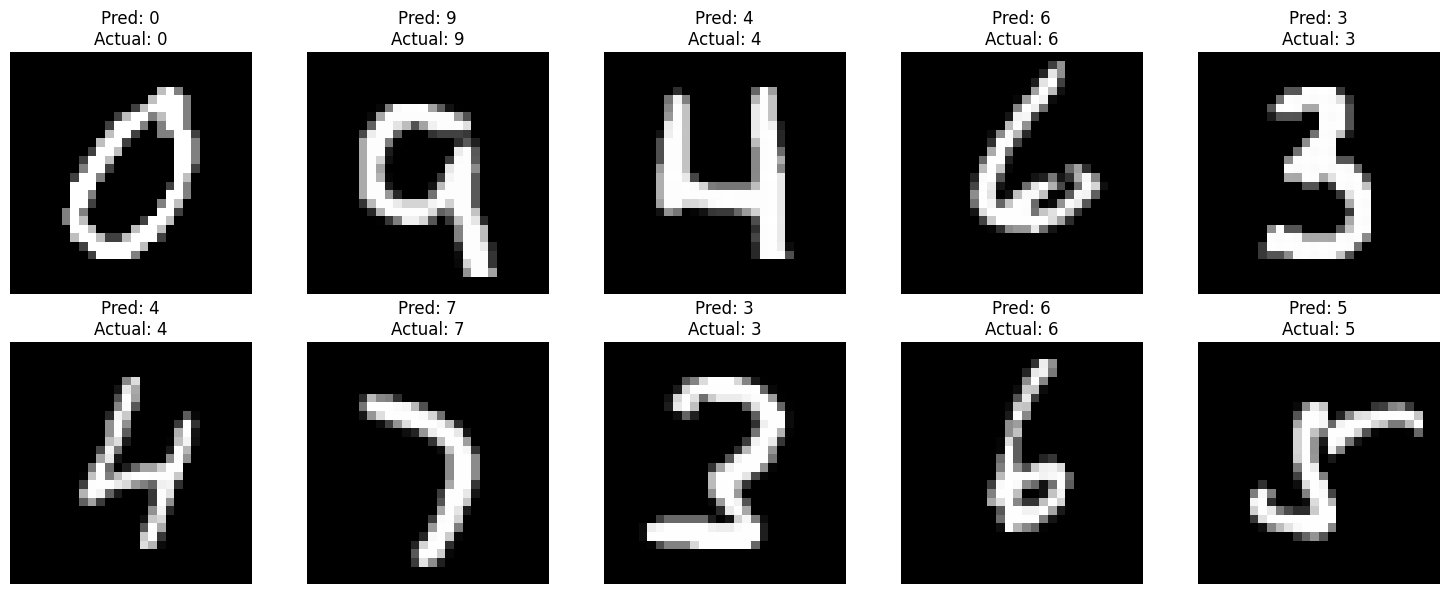

In [ ]:
train_predictions = predict(X, parameters)
Y_true = np.argmax(Y, axis=0)
indices = np.random.choice(X.shape[1], 10, replace=False)
plt.figure(figsize=(15, 6))
for i, idx in enumerate(indices):
    image = X[:, idx].reshape(28, 28)
    plt.subplot(2, 5, i + 1)
    plt.imshow(image, cmap="gray")
    plt.title(f"Pred: {train_predictions[idx]}\nActual: {Y_true[idx]}")
    plt.axis("off")

plt.tight_layout()
plt.show()